In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", context="notebook")

DATA_PATH = Path("output/sima_2020_2025_limpio.parquet")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró {DATA_PATH}. Ejecuta primero la Etapa 1."
    )

df = pd.read_parquet(DATA_PATH)
df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])

contaminantes = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2"]
meteorologicas = ["PRS", "RAINF", "RH", "SR", "TOUT", "WSR", "WDR"]
variables_movilidad = ["año_archivo", "mes", "hora", "dia_semana", "es_fin_de_semana"]
variables_categoricas = ["estación", "año_archivo", "mes", "hora", "dia_semana", "temporada", "es_fin_de_semana"]

print(f"Base cargada: {DATA_PATH}")
print(f"Registros: {len(df):,} | Columnas: {df.shape[1]}")
print("La base no incluye tráfico vehicular, fecha de apertura de líneas ni zonas de tratamiento.")

Base cargada: output\sima_2020_2025_limpio.parquet
Registros: 688,184 | Columnas: 33
La base no incluye tráfico vehicular, fecha de apertura de líneas ni zonas de tratamiento.


# ETAPA 2. Comprensión y preparación de los datos

## Contexto y selección inicial de variables

La base contiene mediciones horarias de calidad del aire y variables meteorológicas en estaciones de monitoreo de la Zona Metropolitana de Monterrey entre 2020 y 2025.

Para estudiar la hipótesis se consideran tres grupos:

- **Resultados ambientales:** `CO`, `NO`, `NO2`, `NOX`, `O3`, `PM10`, `PM2.5` y `SO2`.
- **Aproximaciones temporales a movilidad:** año, mes, hora, día de la semana y fin de semana. No son una medición directa del tráfico.
- **Variables de control meteorológico:** presión, lluvia, humedad, radiación solar, temperatura, velocidad y dirección del viento.

**Hipótesis:** la entrada en operación de nuevas líneas del Metro podría reducir las concentraciones de contaminantes al disminuir el tráfico vehicular. Esta etapa identifica variables candidatas y patrones descriptivos; no prueba causalidad porque la base no registra directamente tráfico, fechas de apertura ni zonas tratadas.

In [10]:
print("Dimensión del dataset")
print(f"Registros: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print(f"Periodo: {df['fecha_hora'].min()} a {df['fecha_hora'].max()}")
print(f"Estaciones: {df['estación'].nunique()}")

descripcion_variables = pd.DataFrame(
    {
        "variable": [
            "fecha_hora", "CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5",
            "PRS", "RAINF", "RH", "SO2", "SR", "TOUT", "WSR", "WDR",
            "estación", "año_archivo", "año", "mes", "hora", "dia_semana",
            "es_fin_de_semana", "temporada", "PM2.5_nivel_cuartil",
        ],
        "descripción": [
            "Fecha y hora de la medición", "Monóxido de carbono", "Óxido nítrico",
            "Dióxido de nitrógeno", "Óxidos de nitrógeno", "Ozono",
            "Partículas suspendidas de diámetro menor o igual a 10 micrómetros",
            "Partículas suspendidas de diámetro menor o igual a 2.5 micrómetros",
            "Presión atmosférica", "Precipitación", "Humedad relativa", "Dióxido de azufre",
            "Radiación solar", "Temperatura exterior", "Velocidad del viento", "Dirección del viento",
            "Estación de monitoreo", "Año del archivo fuente", "Año de la fecha", "Mes",
            "Hora del día", "Día de la semana", "Indicador de fin de semana", "Temporada", "Nivel de PM2.5 por cuartil",
        ],
        "tipo": [
            "Temporal", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
            "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico",
            "Categórico", "Numérico", "Numérico", "Numérico", "Numérico", "Numérico", "Categórico", "Categórico", "Categórico",
        ],
    }
)
descripcion_variables["valores_posibles"] = [
    df[col].dropna().unique()[:10].tolist() for col in descripcion_variables["variable"]
]
descripcion_variables["nulos"] = [df[col].isna().sum() for col in descripcion_variables["variable"]]
descripcion_variables["porcentaje_nulos"] = [df[col].isna().mean() * 100 for col in descripcion_variables["variable"]]
display(descripcion_variables)

Dimensión del dataset
Registros: 688,184
Columnas: 33
Periodo: 2020-01-01 00:00:00 a 2025-06-30 23:00:00
Estaciones: 15


,variable,descripción,tipo,valores_posibles,nulos,porcentaje_nulos
0,fecha_hora,Fecha y hora de la medición,Temporal,"[2020-01-01 00:00:00, 2020-01-01 01:00:00, 202...",0,0.00
1,CO,Monóxido de carbono,Numérico,"[3.28, 3.35, 3.22, 3.26, 3.25, 3.36, 3.4, 3.24...",81505,11.84
2,NO,Óxido nítrico,Numérico,"[3.3, 3.1, 3.2, 4.7, 5.0, 4.2, 4.0, 6.0, 6.1, ...",96946,14.09
3,NO2,Dióxido de nitrógeno,Numérico,"[6.5, 5.6, 7.2, 10.6, 10.1, 9.5, 8.6, 8.5, 7.9...",109711,15.94
4,NOX,Óxidos de nitrógeno,Numérico,"[9.8, 8.8, 10.4, 15.3, 15.1, 13.7, 12.5, 14.5,...",104318,15.16
5,O3,Ozono,Numérico,"[19.0, 18.0, 14.0, 5.0, 3.0, 4.0, 6.0, 8.0, 9....",88618,12.88
6,PM10,Partículas suspendidas de diámetro menor o igu...,Numérico,"[112.01, 100.01, 106.2, 141.86, 122.24, 113.71...",17992,2.61
7,PM2.5,Partículas suspendidas de diámetro menor o igu...,Numérico,"[85.64, 72.39, 70.25, 93.72, 83.93, 77.28, 67....",131175,19.06
8,PRS,Presión atmosférica,Numérico,"[713.6, 712.8, 712.4, 712.0, 711.9, 711.8, 711...",26056,3.79
9,RAINF,Precipitación,Numérico,"[0.0, 0.85, 0.04, 0.01, 0.54, 0.19, 0.31, 0.22...",27002,3.92


## Estadística descriptiva de las variables candidatas

Se calculan medidas de tendencia central y dispersión para todos los contaminantes registrados. Las variables meteorológicas se resumen por separado para distinguir resultados ambientales de posibles variables de control.

In [11]:
def resumen_numerico(columnas):
    estadistica = []
    for variable in columnas:
        serie = df[variable].dropna()
        estadistica.append(
            {
                "variable": variable,
                "n_validos": serie.size,
                "promedio": serie.mean(),
                "mediana": serie.median(),
                "moda": serie.mode().tolist(),
                "mínimo": serie.min(),
                "máximo": serie.max(),
                "rango": serie.max() - serie.min(),
                "varianza": serie.var(),
                "desviación_estándar": serie.std(),
                "asimetría": serie.skew(),
            }
        )
    return pd.DataFrame(estadistica).set_index("variable")

print("Contaminantes")
display(resumen_numerico(contaminantes))
print("Variables meteorológicas")
display(resumen_numerico(meteorologicas))

Contaminantes


,n_validos,promedio,mediana,moda,mínimo,máximo,rango,varianza,desviación_estándar,asimetría
variable,,,,,,,,,,
CO,606679,1.38,1.23,[0.7],0.00,37.00,37.00,0.77,0.88,1.72
NO,591238,12.03,4.90,[2.6],0.30,945.10,944.80,524.68,22.91,7.66
NO2,578473,14.36,11.20,[0.5],0.00,188.60,188.60,130.56,11.43,2.02
NOX,583866,26.23,17.10,[0.5],0.50,971.80,971.30,870.68,29.51,4.79
O3,599566,26.77,23.00,[16.0],0.50,265.00,264.50,359.33,18.96,1.29
PM10,670192,59.14,50.00,[39.0],1.00,1001.00,1000.00,1749.49,41.83,3.97
PM2.5,557009,20.54,17.00,[10.0],0.00,999.00,999.00,250.14,15.82,5.63
SO2,610076,4.92,3.80,[2.8],0.00,404.70,404.70,21.99,4.69,12.16


Variables meteorológicas


,n_validos,promedio,mediana,moda,mínimo,máximo,rango,varianza,desviación_estándar,asimetría
variable,,,,,,,,,,
PRS,662128,715.22,714.30,[729.0],0.00,750.00,750.00,91.70,9.58,-0.58
RAINF,661182,0.02,0.00,[0.0],0.00,360.00,360.00,1.11,1.05,249.01
RH,625616,56.79,59.00,[77.0],0.00,100.00,100.00,454.68,21.32,-0.33
SR,669910,-0.03,0.01,[0.0],-9999.00,501.00,10500.00,1725.06,41.53,-236.05
TOUT,651852,23.01,23.89,[24.4],-9999.00,785.00,10784.00,1033.39,32.15,-279.47
WSR,652775,8.39,7.40,[1.4],0.10,227.10,227.00,43.59,6.60,7.02
WDR,640155,140.31,116.00,[105.0],1.00,360.00,359.00,8925.97,94.48,0.76


## Variables cualitativas

Las tablas de frecuencia muestran la distribución por estación, año y temporada. La mediana ordinal se calcula para `PM2.5_nivel_cuartil`, cuya escala ordenada va de menor a mayor concentración.

In [12]:
for variable in variables_categoricas:
    frecuencia = (
        df[variable]
        .value_counts(dropna=False)
        .rename_axis(variable)
        .reset_index(name="frecuencia")
    )
    frecuencia["porcentaje"] = frecuencia["frecuencia"] / len(df) * 100
    print(f"Distribución de {variable}")
    display(frecuencia)

nivel_ordinal = df["PM2.5_nivel_cuartil"].dropna()
if isinstance(nivel_ordinal.dtype, pd.CategoricalDtype):
    codigos = nivel_ordinal.cat.codes
    codigo_mediano = int(round(codigos.median()))
    mediana_ordinal = nivel_ordinal.cat.categories[codigo_mediano]
else:
    mediana_ordinal = nivel_ordinal.median()
print("Mediana ordinal de PM2.5_nivel_cuartil, como indicador complementario:")
print(mediana_ordinal)

Distribución de estación


,estación,frecuencia,porcentaje
0,CE,48190,7.00
1,SE,48183,7.00
2,NO,48181,7.00
3,NE,48180,7.00
4,NTE,48180,7.00
5,NO2,48179,7.00
6,SE2,48179,7.00
7,NTE2,48178,7.00
8,SE3,48178,7.00
9,SO2,48178,7.00


Distribución de año_archivo


,año_archivo,frecuencia,porcentaje
0,2024,131741,19.14
1,2023,131370,19.09
2,2022,123383,17.93
3,2021,122629,17.82
4,2020,114102,16.58
5,2025,64959,9.44


Distribución de mes


...

Distribución de temporada


,temporada,frecuencia,porcentaje
0,lluvias,271464,39.45
1,seca-fria,226898,32.97
2,seca-calida,189822,27.58


Distribución de es_fin_de_semana


,es_fin_de_semana,frecuencia,porcentaje
0,False,491428,71.41
1,True,196756,28.59


Mediana ordinal de PM2.5_nivel_cuartil, como indicador complementario:
medio


## Exploración visual

Los boxplots permiten comparar dispersión y valores atípicos; los histogramas muestran la forma de la distribución. La línea temporal por año y hora sirve para buscar patrones compatibles con cambios en movilidad, sin interpretarlos como causalidad.

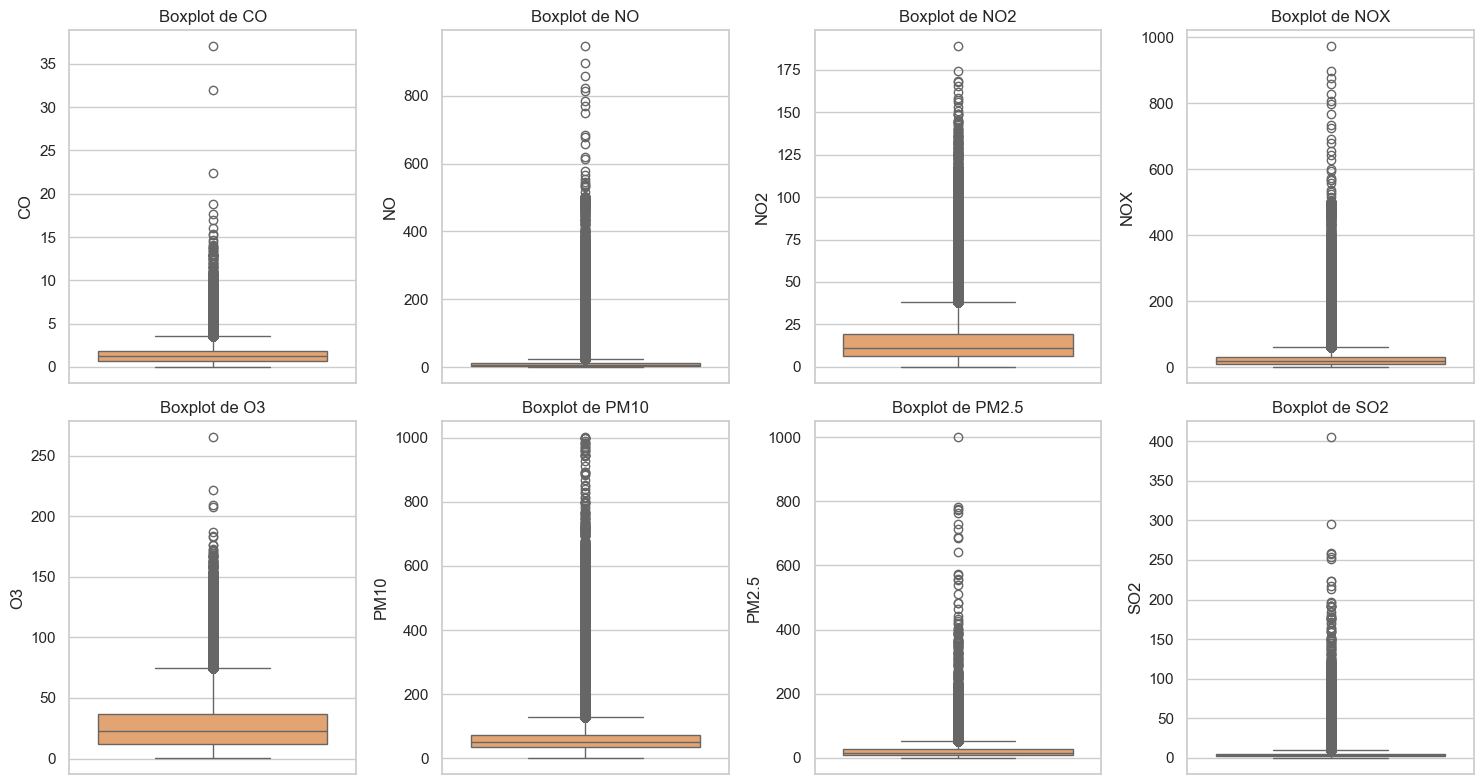

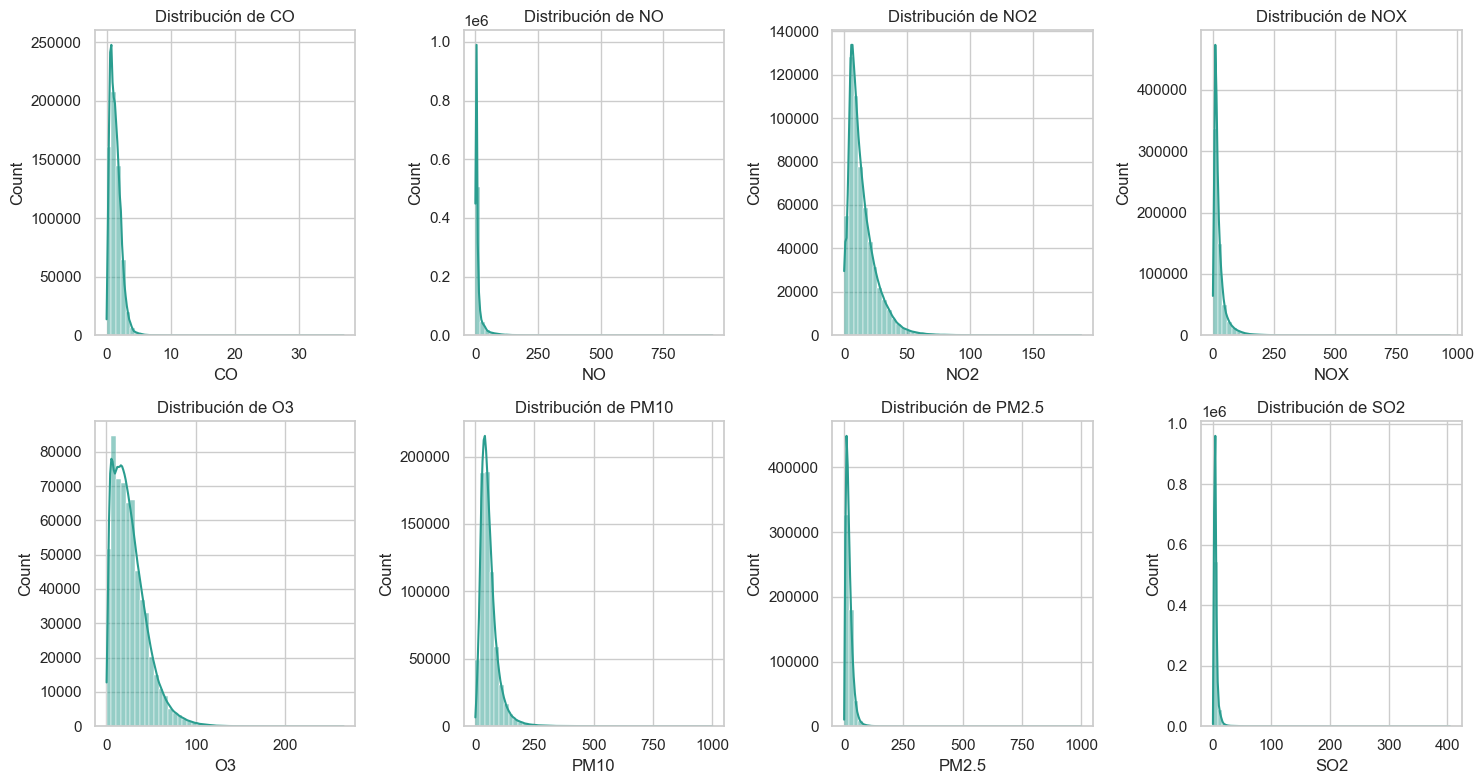

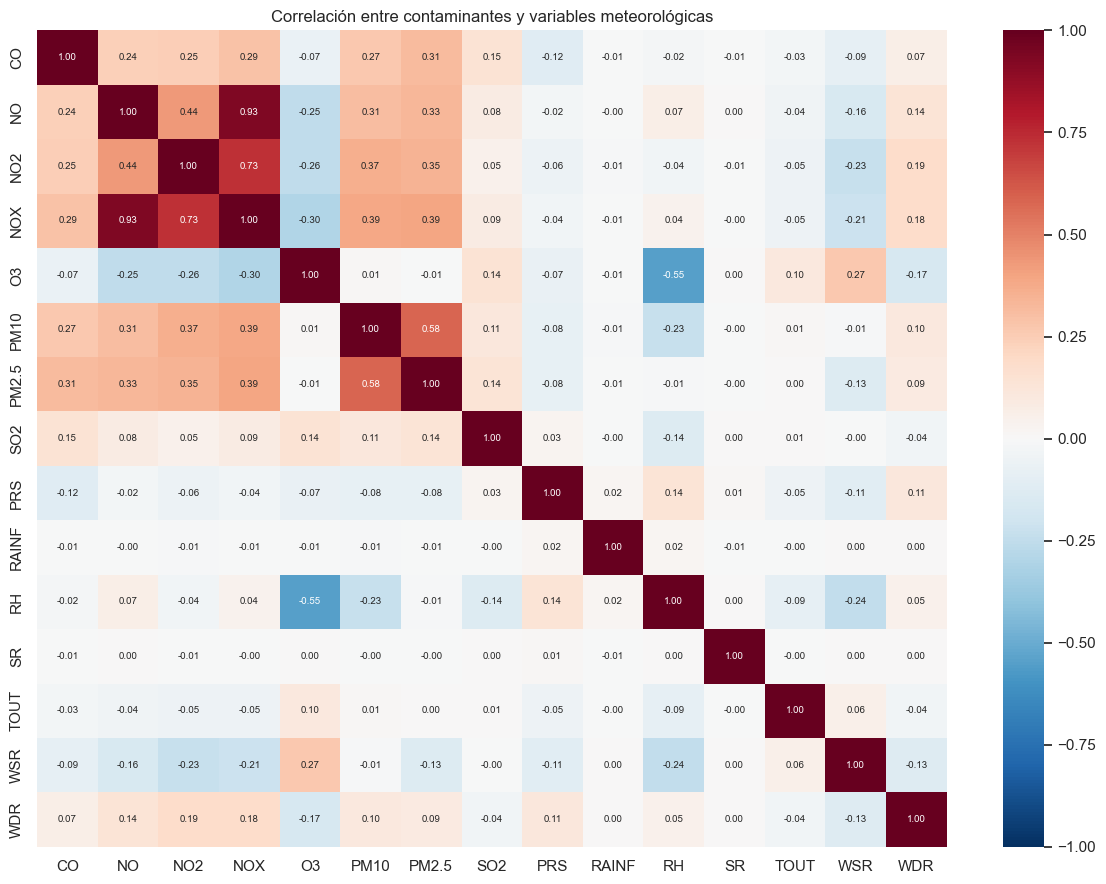

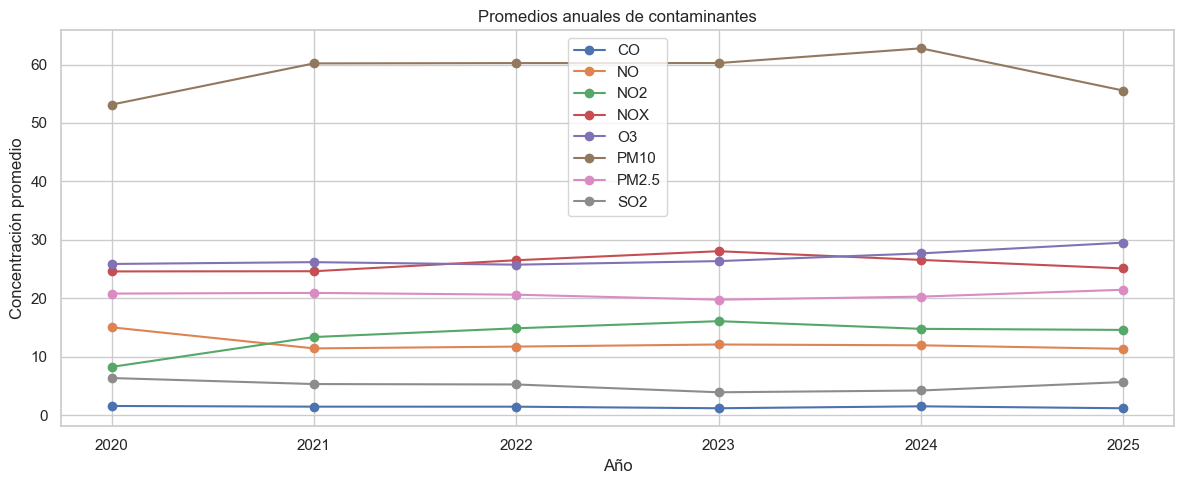

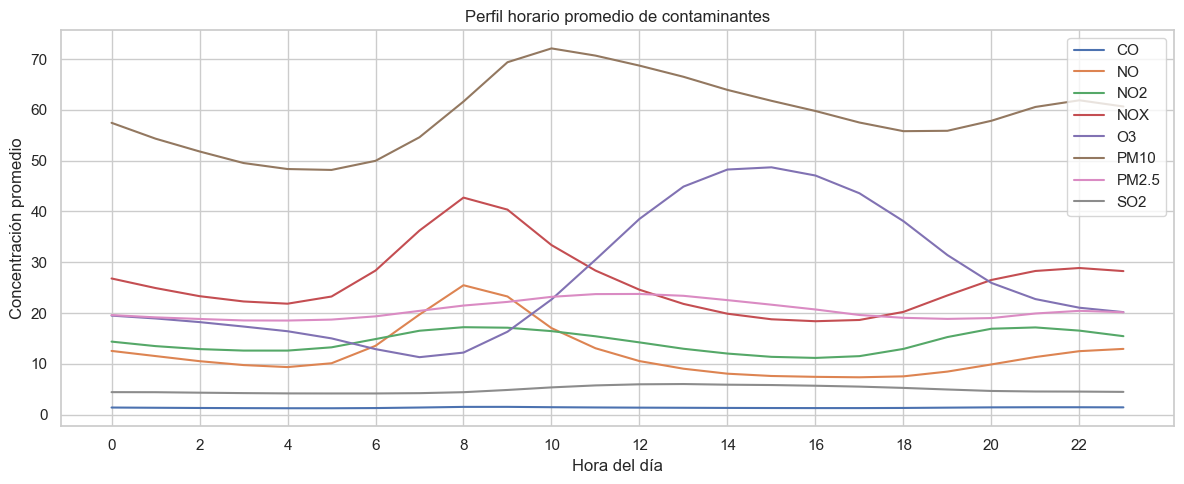

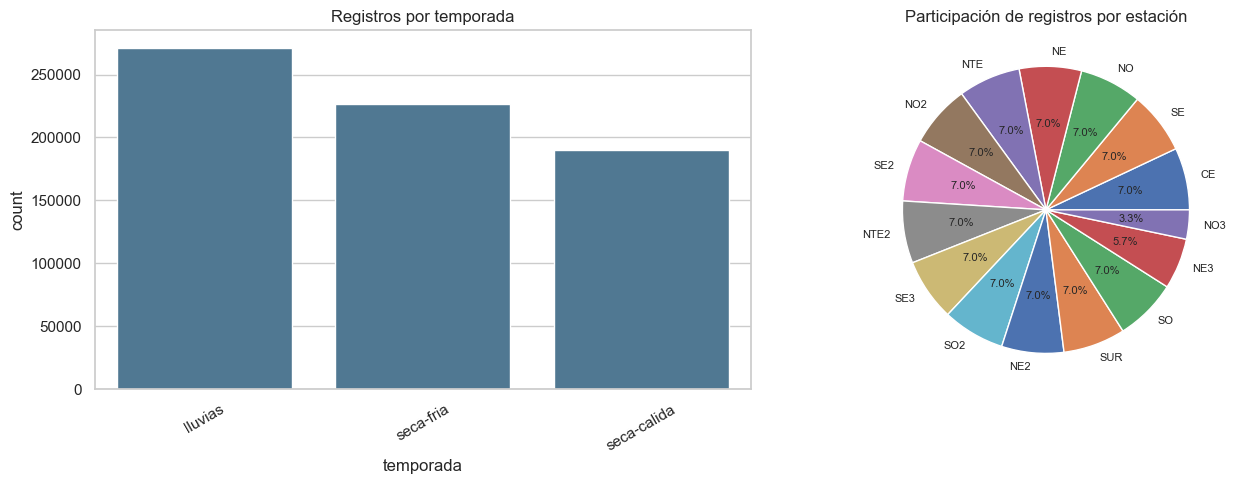

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for axis, variable in zip(axes.flat, contaminantes):
    sns.boxplot(data=df, y=variable, ax=axis, color="#f4a261")
    axis.set_title(f"Boxplot de {variable}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for axis, variable in zip(axes.flat, contaminantes):
    sns.histplot(df[variable].dropna(), bins=50, kde=True, ax=axis, color="#2a9d8f")
    axis.set_title(f"Distribución de {variable}")
    axis.set_xlabel(variable)
plt.tight_layout()
plt.show()

variables_correlacion = contaminantes + meteorologicas
correlacion = df[variables_correlacion].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(correlacion, annot=True, vmin=-1, vmax=1, cmap="RdBu_r", fmt=".2f", annot_kws={"size": 7})
plt.title("Correlación entre contaminantes y variables meteorológicas")
plt.tight_layout()
plt.show()

promedios_anuales = df.groupby("año_archivo", observed=True)[contaminantes].mean()
promedios_anuales.plot(figsize=(12, 5), marker="o", title="Promedios anuales de contaminantes")
plt.ylabel("Concentración promedio")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

promedios_hora = df.groupby("hora", observed=True)[contaminantes].mean()
promedios_hora.plot(figsize=(12, 5), title="Perfil horario promedio de contaminantes")
plt.ylabel("Concentración promedio")
plt.xlabel("Hora del día")
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="temporada", order=df["temporada"].value_counts().index, ax=axes[0], color="#457b9d")
axes[0].set_title("Registros por temporada")
axes[0].tick_params(axis="x", rotation=30)

proporcion_estaciones = df["estación"].value_counts()
axes[1].pie(proporcion_estaciones, labels=proporcion_estaciones.index, autopct="%.1f%%", textprops={"fontsize": 8})
axes[1].set_title("Participación de registros por estación")
plt.tight_layout()
plt.show()

## Verificación y preparación de la calidad de los datos

Se revisan valores faltantes, duplicados, rangos imposibles y consistencia entre partículas. Las correcciones se aplican a una copia de análisis (`df_preparado`) para conservar intacta la base maestra de la Etapa 1.

In [14]:
faltantes = (
    df.isna().sum()
    .rename("nulos")
    .to_frame()
    .assign(porcentaje_nulos=lambda tabla: tabla["nulos"] / len(df) * 100)
    .query("nulos > 0")
    .sort_values("nulos", ascending=False)
)
print("Valores faltantes por variable")
display(faltantes)

print(f"Filas duplicadas exactas: {df.duplicated().sum():,}")
print("Categorías observadas")
for variable in ["estación", "temporada", "PM2.5_nivel_cuartil"]:
    print(f"{variable}: {df[variable].dropna().unique().tolist()}")

concentraciones = ["CO", "NO", "NO2", "NOX", "O3", "PM10", "PM2.5", "SO2"]
negativos = {variable: int((df[variable] < 0).sum()) for variable in concentraciones}
negativos = pd.Series(negativos, name="valores_negativos")
print("Valores negativos en concentraciones")
display(negativos.to_frame().query("valores_negativos > 0"))

inconsistencias_pm = int((df["PM2.5"] > df["PM10"]).sum())
print(f"Registros con PM2.5 > PM10: {inconsistencias_pm:,}")

# Se corrigen solo errores físicos evidentes en la copia usada para el análisis.
df_preparado = df.copy()
for variable in concentraciones:
    df_preparado.loc[df_preparado[variable] < 0, variable] = np.nan
df_preparado.loc[df_preparado["PM2.5"] > df_preparado["PM10"], ["PM2.5", "PM10"]] = np.nan

print("Correcciones aplicadas a df_preparado:")
print(f"Nulos agregados: {df_preparado.isna().sum().sum() - df.isna().sum().sum():,}")
print("La base original df no fue modificada.")

Valores faltantes por variable


,nulos,porcentaje_nulos
PM2.5,131175,19.06
PM2.5_nivel_cuartil,131175,19.06
NO2,109711,15.94
NOX,104318,15.16
NO,96946,14.09
O3,88618,12.88
CO,81505,11.84
SO2,78108,11.35
RH,62568,9.09
WDR,48029,6.98


Filas duplicadas exactas: 0
Categorías observadas
estación: ['CE', 'NE', 'NE2', 'NE3', 'NO', 'NO2', 'NO3', 'NTE', 'NTE2', 'SE', 'SE2', 'SE3', 'SO', 'SO2', 'SUR']
temporada: ['seca-fria', 'seca-calida', 'lluvias']
PM2.5_nivel_cuartil: ['muy_alto', 'medio', 'bajo', 'alto']
Valores negativos en concentraciones


,valores_negativos


Registros con PM2.5 > PM10: 5,861
Correcciones aplicadas a df_preparado:
Nulos agregados: 11,722
La base original df no fue modificada.


## Lectura inicial frente a la hipótesis

La siguiente tabla permite identificar si los promedios y los picos horarios cambian entre años. El resultado debe interpretarse como evidencia exploratoria: para atribuir una reducción al Metro se necesitarían fechas exactas de apertura, estaciones tratadas y de comparación, además de controlar meteorología, temporada y cambios en la red de monitoreo.

In [15]:
resumen_anual = (
    df_preparado.groupby("año_archivo", observed=True)[contaminantes]
    .agg(["mean", "median", "max"])
    .round(2)
)
print("Promedios, medianas y máximos por año")
display(resumen_anual)

picos_horarios = (
    df_preparado.groupby("hora", observed=True)[contaminantes]
    .quantile(0.90)
    .round(2)
)
print("Percentil 90 por hora, útil para estudiar picos de movilidad")
display(picos_horarios)

Promedios, medianas y máximos por año


CO                 NO                 NO2                 NOX  \
            mean median   max  mean median    max  mean median    max  mean   
año_archivo                                                                   
2020        1.55   1.47 17.71 15.02   3.20 500.00  8.24   4.00 188.60 24.59   
2021        1.44   1.25 32.00 11.41   4.90 769.30 13.35  10.30  96.20 24.62   
2022        1.43   1.41  7.42 11.72   5.10 945.10 14.85  11.30 167.80 26.50   
2023        1.16   1.03 14.03 12.08   5.00 500.00 16.07  12.90 158.00 28.05   
2024        1.49   1.20 37.00 11.94   5.30 404.70 14.76  11.90 126.00 26.56   
2025        1.16   0.94  9.79 11.34   4.40 325.60 14.57  11.30 165.10 25.10   

                             O3                PM10                PM2.5  \
            median    max  mean median    max  mean median     max  mean   
año_archivo                                                                
2020         11.00 500.00 25.86  23.00 159.00 54.00  46.00  763.00 20.66   
2021         15.60 806.90 26.17  23.00 265.00 60.31  52.00  795.00 20.83   
2022         17.10 971.80 25.74  22.00 151.80 60.48  51.00 1001.00 20.57   
2023         19.10 500.00 26.35  23.00 171.00 60.44  51.00 1000.00 19.66   
2024         18.20 500.00 27.67  23.00 183.00 63.00  54.00  999.00 20.19   
2025         15.80 399.90 29.51  26.00 184.00 55.90  45.00  811.00 21.34   

                           SO2                
            median    max mean median    max  
año_archivo                                   
2020         17.30 205.94 6.34   5.10 192.10  
2021         17.28 324.00 5.30   3.80 295.10  
2022         17.00 442.00 5.23   4.40 190.30  
2023         16.00 763.00 3.90   3.20 222.90  
2024         16.00 729.00 4.20   3.50 150.10  
2025         18.00 340.25 5.65   4.50 404.70

Percentil 90 por hora, útil para estudiar picos de movilidad


,CO,NO,NO2,NOX,O3,PM10,PM2.5,SO2
hora,,,,,,,,
0,2.58,32.25,31.17,60.30,35.00,103.00,37.00,7.20
1,2.50,28.70,29.51,55.10,34.00,99.00,37.00,7.20
2,2.43,25.70,28.10,51.20,33.00,94.00,36.25,7.00
3,2.38,23.40,27.30,48.80,32.00,89.00,35.53,6.80
4,2.35,22.40,26.50,47.60,30.00,87.00,35.36,6.70
5,2.33,24.30,26.90,49.60,29.00,86.00,35.50,6.60
6,2.38,35.60,28.30,61.10,26.00,89.00,36.17,6.60
7,2.53,50.50,30.20,78.50,23.00,97.00,38.00,6.70
8,2.74,63.80,31.50,93.90,23.40,110.00,40.00,7.20
